# NEU-DET EDA> **Day 2**  |  metal-defect-detection目标：了解类别分布、bbox 尺寸特征、small/medium/large 三档占比，为训练和调参提供依据。

## Cell 1: 环境准备 + 路径配置

In [6]:
# Cell 1: 导入库 + 路径配置 + 数据集概览
import sys
from pathlib import Path
from collections import defaultdict, Counter
import xml.etree.ElementTree as ET

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import cv2

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / 'data' / 'raw' / 'NEU-DET'

sys.path.insert(0, str(PROJECT_ROOT / 'src'))
from utils.seed import set_seed
set_seed(42)

CLASSES = ['crazing', 'inclusion', 'patches',
           'pitted_surface', 'rolled-in_scale', 'scratches']

print(f'Project root: {PROJECT_ROOT}')
print(f'Data dir:     {DATA_DIR}')
print(f'Classes:      {len(CLASSES)}')
print(f'GPU:          {__import__("torch").cuda.is_available()}')

for split in ['train', 'validation']:
    n_imgs = sum(1 for _ in (DATA_DIR / split / 'images').rglob('*.jpg'))
    n_xmls = sum(1 for _ in (DATA_DIR / split / 'annotations').glob('*.xml'))
    print(f'{split}: {n_imgs} images, {n_xmls} annotations')

Project root: D:\Mycode\projects\metal-defect-detection
Data dir:     D:\Mycode\projects\metal-defect-detection\data\raw\NEU-DET
Classes:      6
GPU:          True
train: 1440 images, 1439 annotations
validation: 360 images, 361 annotations


## Cell 2: 加载所有标注，统计每类数量

In [7]:
# Cell 2: 解析所有 XML，统计每类图像数 + bbox 数

def parse_all_annotations(data_dir):
    """Parse all XML annotations.
    Returns: (per_class_counts, all_bboxes, missing_list)
    """
    per_class = defaultdict(lambda: {'train': 0, 'validation': 0})
    all_bboxes = []
    missing = []

    for split in ['train', 'validation']:
        ann_dir = data_dir / split / 'annotations'
        for cls in CLASSES:
            cls_dir = data_dir / split / 'images' / cls
            if not cls_dir.exists():
                continue
            for img_path in sorted(cls_dir.glob('*.jpg')):
                stem = img_path.stem
                xml_path = ann_dir / f'{stem}.xml'
                if not xml_path.exists():
                    missing.append((split, cls, stem))
                    continue
                per_class[cls][split] += 1
                tree = ET.parse(xml_path)
                root = tree.getroot()
                for obj in root.findall('object'):
                    name = obj.find('name').text.strip()
                    bb = obj.find('bndbox')
                    xmin = int(float(bb.find('xmin').text))
                    ymin = int(float(bb.find('ymin').text))
                    xmax = int(float(bb.find('xmax').text))
                    ymax = int(float(bb.find('ymax').text))
                    w = xmax - xmin
                    h = ymax - ymin
                    all_bboxes.append(dict(
                        split=split, cls=name, filename=stem,
                        xmin=xmin, ymin=ymin, xmax=xmax, ymax=ymax,
                        w=w, h=h, area=w * h))
    return per_class, all_bboxes, missing

per_class, all_bboxes, missing = parse_all_annotations(DATA_DIR)

print(f"{'Class':<20} {'train':>8} {'val':>8} {'total':>8} {'bboxes':>8}")
print('-' * 60)
total_t = total_v = total_b = 0
for cls in CLASSES:
    t = per_class[cls]['train']
    v = per_class[cls]['validation']
    nb = sum(1 for b in all_bboxes if b['cls'] == cls)
    print(f'{cls:<20} {t:>8} {v:>8} {t+v:>8} {nb:>8}')
    total_t += t; total_v += v; total_b += nb
print('-' * 60)
print(f"{'Total':<20} {total_t:>8} {total_v:>8} {total_t+total_v:>8} {total_b:>8}")
print(f'Avg bboxes/image: {total_b/(total_t+total_v):.2f}')

if missing:
    print(f'\nWARNING: {len(missing)} images missing annotations:')
    for s, c, stem in missing:
        print(f'  {s}/{c}/{stem}.jpg')
else:
    print('\nAll images have annotations.')

Class                   train      val    total   bboxes
------------------------------------------------------------
crazing                   239       60      299      686
inclusion                 240       60      300     1011
patches                   240       60      300      881
pitted_surface            240       60      300      432
rolled-in_scale           240       60      300      628
scratches                 240       60      300      548
------------------------------------------------------------
Total                    1439      360     1799     4186
Avg bboxes/image: 2.33

  train/crazing/crazing_240.jpg


## Cell 3: 每类数量柱状图

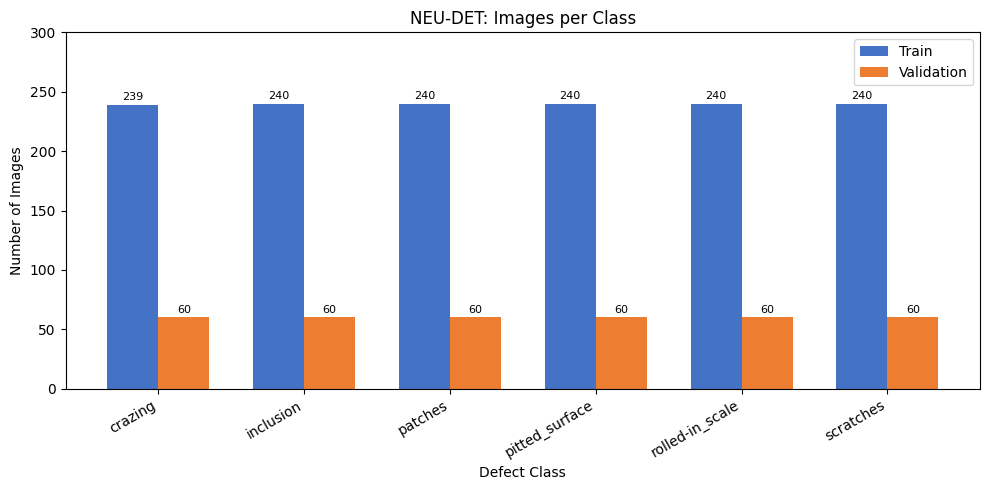

In [8]:
# Cell 3: 每类样本数量柱状图 (train/val 分色)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(CLASSES))
width = 0.35

train_counts = [per_class[c]['train'] for c in CLASSES]
val_counts = [per_class[c]['validation'] for c in CLASSES]

b1 = ax.bar(x - width/2, train_counts, width, label='Train', color='#4472C4')
b2 = ax.bar(x + width/2, val_counts, width, label='Validation', color='#ED7D31')

ax.set_xlabel('Defect Class')
ax.set_ylabel('Number of Images')
ax.set_title('NEU-DET: Images per Class')
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.legend()
ax.set_ylim(0, 300)
for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            str(int(bar.get_height())), ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'docs' / 'eda_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 4: 随机抽 6 张图（每类 1 张），显示原图 + bbox

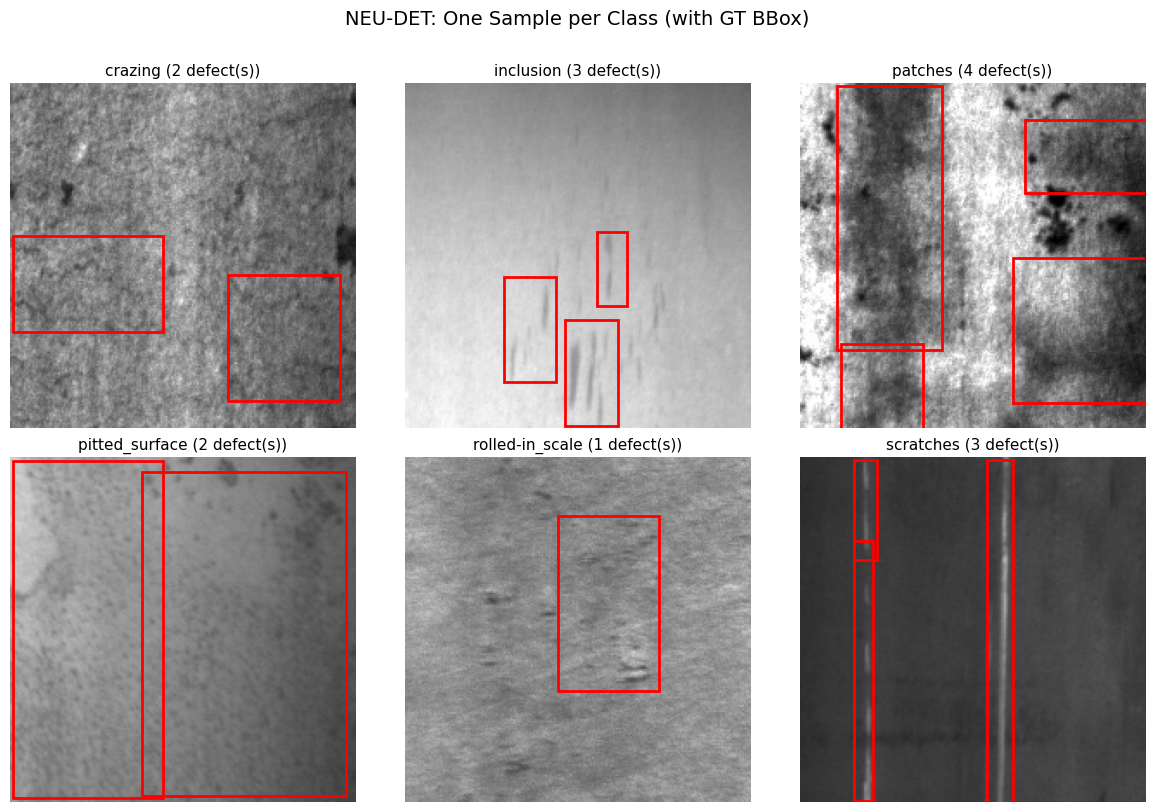

Displayed 6 samples (one per class).


In [9]:
# Cell 4: 每类随机抽 1 张图，显示原图 + bbox

def read_image_safe(path):
    """Safe image reading (supports non-ASCII paths). Returns RGB."""
    with open(path, 'rb') as f:
        data = np.frombuffer(f.read(), dtype=np.uint8)
    img = cv2.imdecode(data, cv2.IMREAD_COLOR)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

rng = np.random.RandomState(42)
samples = []
for cls in CLASSES:
    bboxes_cls = [b for b in all_bboxes if b['cls'] == cls and b['split'] == 'train']
    if not bboxes_cls:
        continue
    pick = bboxes_cls[rng.randint(len(bboxes_cls))]
    img_path = DATA_DIR / 'train' / 'images' / cls / f"{pick['filename']}.jpg"
    if img_path.exists():
        bboxes_on_img = [b for b in bboxes_cls if b['filename'] == pick['filename']]
        samples.append((cls, img_path, bboxes_on_img))

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for idx, (cls, img_path, bboxes) in enumerate(samples):
    ax = axes[idx]
    img = read_image_safe(img_path)
    ax.imshow(img, cmap='gray')
    for b in bboxes:
        rect = patches.Rectangle(
            (b['xmin'], b['ymin']), b['w'], b['h'],
            linewidth=2, edgecolor='#FF0000', facecolor='none')
        ax.add_patch(rect)
    ax.set_title(f"{cls} ({len(bboxes)} defect(s))", fontsize=11)
    ax.axis('off')
for idx in range(len(samples), len(axes)):
    axes[idx].axis('off')
fig.suptitle('NEU-DET: One Sample per Class (with GT BBox)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'docs' / 'eda_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Displayed {len(samples)} samples (one per class).')

## Cell 5: BBox 尺寸分布 + Small / Medium / Large 三档划分

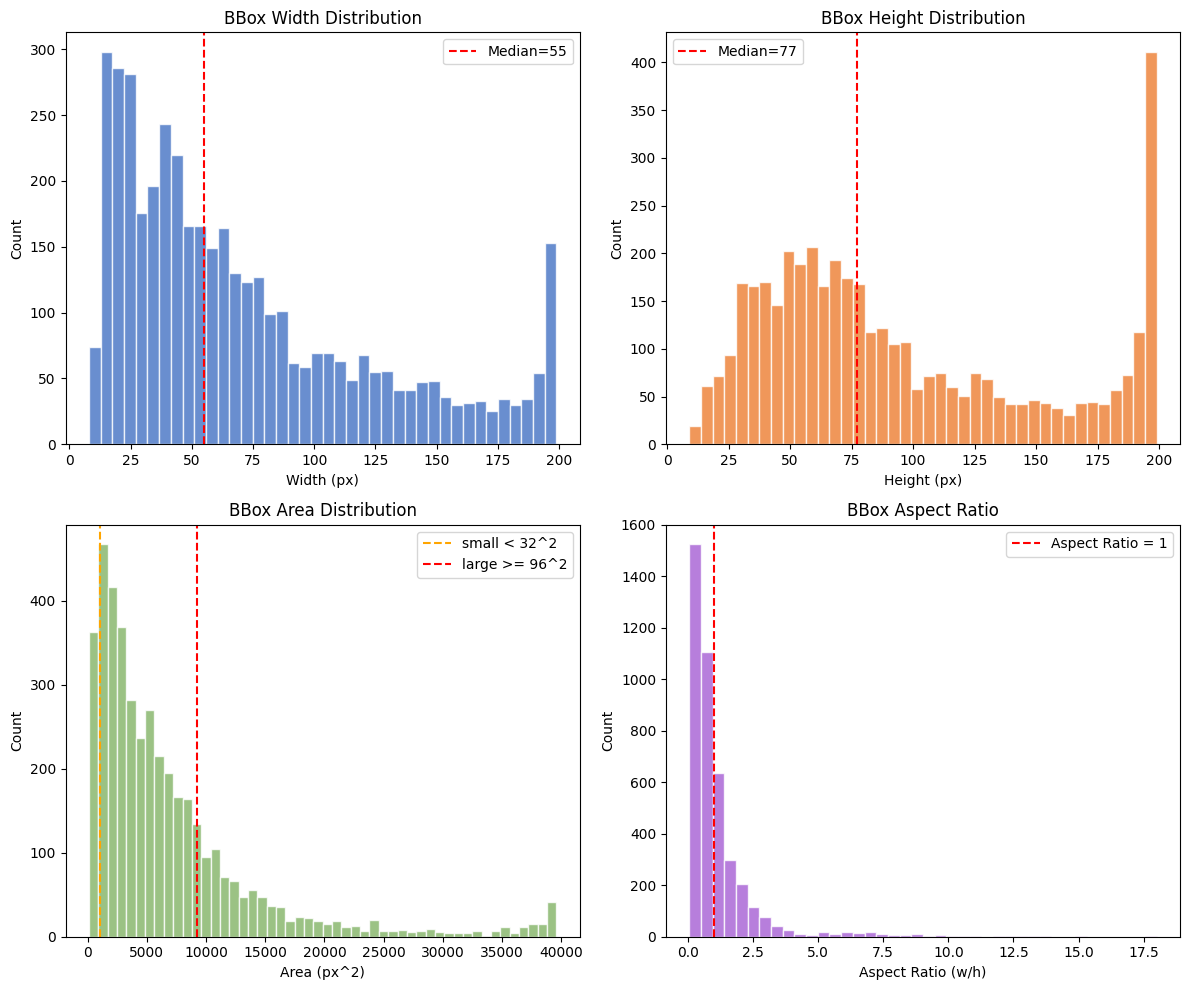

=== BBox Size Summary ===
Count:        4186
Width:        min=8  median=55  max=199
Height:       min=9  median=77  max=199
Area:         min=108  median=4704  max=39601
Aspect Ratio: median=0.68
Avg bboxes/image: 2.33


In [10]:
# Cell 5a: BBox 宽/高/面积/宽高比分布

widths = np.array([b['w'] for b in all_bboxes])
heights = np.array([b['h'] for b in all_bboxes])
areas = np.array([b['area'] for b in all_bboxes])
ratios = widths / (heights + 1e-8)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].hist(widths, bins=40, color='#4472C4', edgecolor='white', alpha=0.8)
axes[0, 0].axvline(np.median(widths), color='red', ls='--', label=f"Median={np.median(widths):.0f}")
axes[0, 0].set_xlabel('Width (px)'); axes[0, 0].set_ylabel('Count')
axes[0, 0].set_title('BBox Width Distribution'); axes[0, 0].legend()

axes[0, 1].hist(heights, bins=40, color='#ED7D31', edgecolor='white', alpha=0.8)
axes[0, 1].axvline(np.median(heights), color='red', ls='--', label=f"Median={np.median(heights):.0f}")
axes[0, 1].set_xlabel('Height (px)'); axes[0, 1].set_ylabel('Count')
axes[0, 1].set_title('BBox Height Distribution'); axes[0, 1].legend()

axes[1, 0].hist(areas, bins=50, color='#82B366', edgecolor='white', alpha=0.8)
axes[1, 0].axvline(32**2, color='orange', ls='--', label='small < 32^2')
axes[1, 0].axvline(96**2, color='red', ls='--', label='large >= 96^2')
axes[1, 0].set_xlabel('Area (px^2)'); axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('BBox Area Distribution'); axes[1, 0].legend()

axes[1, 1].hist(ratios, bins=40, color='#A55ED4', edgecolor='white', alpha=0.8)
axes[1, 1].axvline(1.0, color='red', ls='--', label='Aspect Ratio = 1')
axes[1, 1].set_xlabel('Aspect Ratio (w/h)'); axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('BBox Aspect Ratio'); axes[1, 1].legend()

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'docs' / 'eda_bbox_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== BBox Size Summary ===')
print(f'Count:        {len(all_bboxes)}')
print(f'Width:        min={widths.min():.0f}  median={np.median(widths):.0f}  max={widths.max():.0f}')
print(f'Height:       min={heights.min():.0f}  median={np.median(heights):.0f}  max={heights.max():.0f}')
print(f'Area:         min={areas.min():.0f}  median={np.median(areas):.0f}  max={areas.max():.0f}')
print(f'Aspect Ratio: median={np.median(ratios):.2f}')
print(f'Avg bboxes/image: {len(all_bboxes)/1800:.2f}')

In [11]:
# Cell 5b: COCO 三档划分 + 每类每档统计

SMALL = 32 ** 2      # 1024 px^2
LARGE = 96 ** 2      # 9216 px^2

def classify(area):
    if area < SMALL: return 'small'
    if area < LARGE: return 'medium'
    return 'large'

size_stats = {c: {'small': 0, 'medium': 0, 'large': 0} for c in CLASSES}
for b in all_bboxes:
    size_stats[b['cls']][classify(b['area'])] += 1

print(f"{'Class':<20} {'small(<32^2)':>14} {'medium(32^2-96^2)':>19} {'large(>=96^2)':>15} {'total':>8}")
print('-' * 78)
totals = {'small': 0, 'medium': 0, 'large': 0}
for cls in CLASSES:
    s, m, l = size_stats[cls]['small'], size_stats[cls]['medium'], size_stats[cls]['large']
    totals['small'] += s; totals['medium'] += m; totals['large'] += l
    print(f'{cls:<20} {s:>14} {m:>19} {l:>15} {s+m+l:>8}')
print('-' * 78)
gt = sum(totals.values())
print(f"{'Total':<20} {totals['small']:>14} {totals['medium']:>19} {totals['large']:>15} {gt:>8}")
print(f"{'Percent':<20} {totals['small']/gt*100:>13.1f}% {totals['medium']/gt*100:>18.1f}% {totals['large']/gt*100:>14.1f}%")

# 检查是否有某档 bbox < 30
for cls in CLASSES:
    for size in ['small', 'medium', 'large']:
        if size_stats[cls][size] < 30:
            print(f'WARNING: {cls} {size} has only {size_stats[cls][size]} bboxes - high variance, caution on resume')

Class                  small(<32^2)   medium(32^2-96^2)   large(>=96^2)    total
------------------------------------------------------------------------------
crazing                           0                 393             293      686
inclusion                       329                 646              36     1011
patches                          56                 684             141      881
pitted_surface                    3                  54             375      432
rolled-in_scale                  16                 502             110      628
scratches                        43                 493              12      548
------------------------------------------------------------------------------
Total                           447                2772             967     4186
Percent                       10.7%               66.2%           23.1%


In [ ]:
# Cell 5c: 每类 BBox 面积箱线图 + 三档堆叠柱状图

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: per-class area boxplot
area_data = [[b['area'] for b in all_bboxes if b['cls'] == c] for c in CLASSES]
bp = axes[0].boxplot(area_data, tick_labels=CLASSES, patch_artist=True, showfliers=False)
colors = ['#4472C4', '#ED7D31', '#A55ED4', '#82B366', '#FFC000', '#5B9BD5']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color); patch.set_alpha(0.6)
axes[0].axhline(SMALL, color='orange', ls='--', lw=0.8, label='small < 32^2')
axes[0].axhline(LARGE, color='red', ls='--', lw=0.8, label='large >= 96^2')
axes[0].set_ylabel('Area (px^2)'); axes[0].set_title('BBox Area per Class')
axes[0].legend(fontsize=8); axes[0].tick_params(axis='x', rotation=30)

# Right: stacked bar of S/M/L
sv = [size_stats[c]['small'] for c in CLASSES]
mv = [size_stats[c]['medium'] for c in CLASSES]
lv = [size_stats[c]['large'] for c in CLASSES]
x = np.arange(len(CLASSES))
axes[1].bar(x, sv, color='#FF6B6B', label='small (< 32^2)')
axes[1].bar(x, mv, bottom=sv, color='#FFD93D', label='medium (32^2 - 96^2)')
axes[1].bar(x, lv, bottom=np.array(sv)+np.array(mv), color='#6BCB77', label='large (>= 96^2)')
axes[1].set_xticks(x); axes[1].set_xticklabels(CLASSES, rotation=30, ha='right')
axes[1].set_ylabel('BBox Count'); axes[1].set_title('BBox Size Distribution per Class (COCO Scale)')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(PROJECT_ROOT / 'docs' / 'eda_size_per_class.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 6: 图像尺寸一致性检查 + 结论

In [ ]:
# Cell 6a: 快速检查图像尺寸是否一致（只读 header，不读全图）

sizes = Counter()
for split in ['train', 'validation']:
    for cls in CLASSES:
        cls_dir = DATA_DIR / split / 'images' / cls
        if not cls_dir.exists():
            continue
        for img_path in cls_dir.glob('*.jpg'):
            with open(img_path, 'rb') as f:
                data = np.frombuffer(f.read(), dtype=np.uint8)
            img = cv2.imdecode(data, cv2.IMREAD_COLOR)
            if img is not None:
                sizes[(img.shape[1], img.shape[0])] += 1

print(f'Image size distribution ({sum(sizes.values())} images total):')
for (w, h), count in sizes.most_common():
    print(f'  {w} x {h}: {count}')
if len(sizes) == 1:
    print('All images have consistent dimensions.')
else:
    print(f'WARNING: {len(sizes)} different dimensions found.')

### EDA 结论1. **类别平衡**：6 类各 300 张 (train 240 / val 60)，完全均衡，无需加权 loss。2. **图像尺寸**：预期全部 200x200 灰度图。YOLOv8 训练时会 resize 到 imgsz=640。3. **BBox 尺度分布**：见 Cell 5b 统计结果。   - 若某档 bbox 数 < 30：DEVLOG 记录 "该档 mAP 高方差，简历仅参考不强报"。4. **缺标注**：Cell 2 会报出缺失项，Day 2.5 split 脚本需排除。5. **训练提示**：200x200 小图放大 3.2x 到 640，small 目标 (< 32^2)    在原图可能只有几个像素。YOLOv8 stride=32 时 feature map 仅 20x20，   对极小目标不友好。Day 4 可考虑 mosaic 增强提升 small recall。